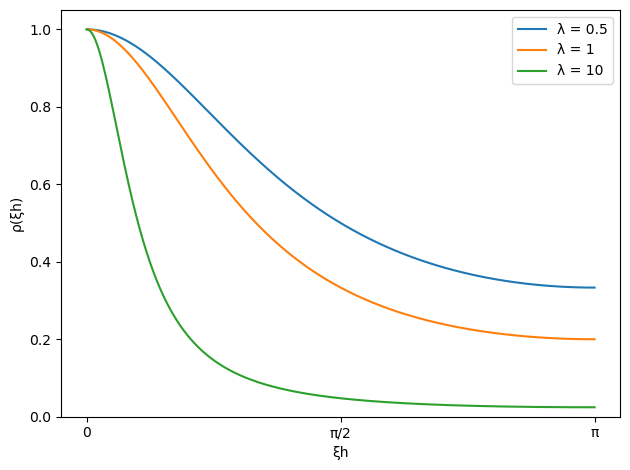

In [1]:
import numpy as np
import matplotlib.pyplot as plt

xh = np.linspace(0, np.pi, 300)
lambdas = [0.5, 1, 10]

for lam in lambdas:
    rho = 1 / (1 + 4 * lam * np.sin(xh / 2)**2)
    plt.plot(xh, rho, label=f'λ = {lam}')

plt.xlabel('ξh')
plt.ylabel('ρ(ξh)')
plt.xticks([0, np.pi/2, np.pi], ['0', 'π/2', 'π'])
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

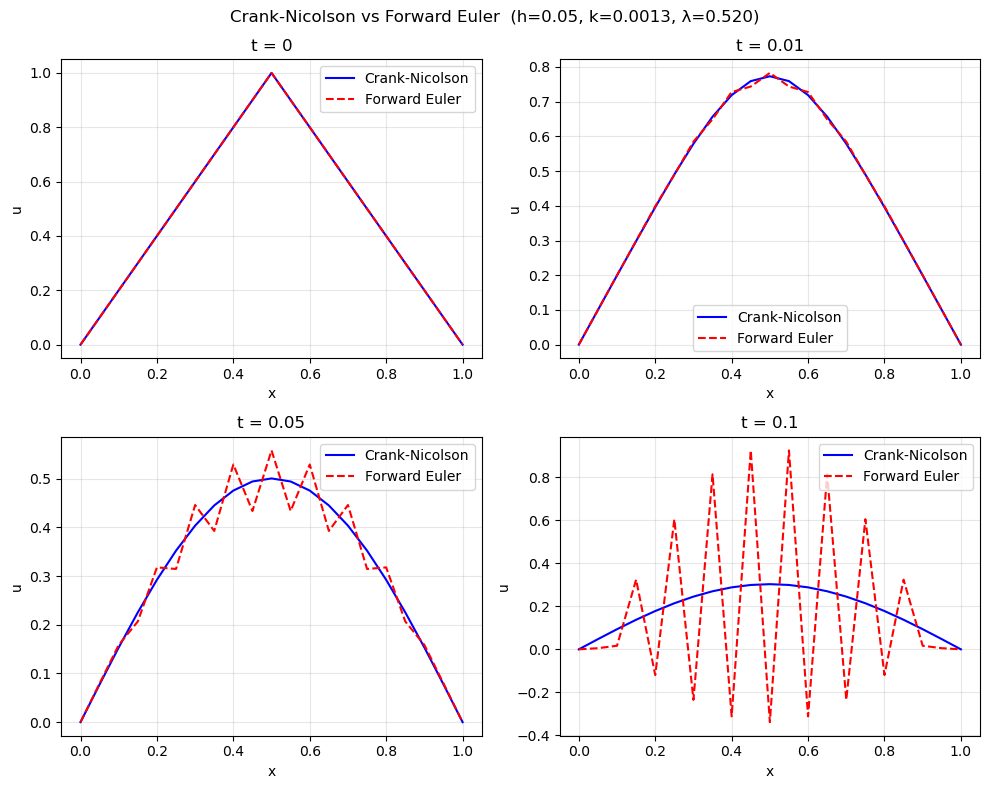

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
h = 0.05
k = 0.0013
lam = k / h**2
x = np.arange(h, 1, h)          # interior points
N = len(x)

# Initial condition
u0 = 1 - 2*np.abs(x - 0.5)

# ── Crank-Nicolson setup ──────────────────────────────────────────
# (I - lam/2 * D+D-) u^{n+1} = (I + lam/2 * D+D-) u^n
# Tridiagonal: main diag = 1+lam, off-diags = -lam/2

d  = (1 + lam) * np.ones(N)      # main diagonal
dl = (-lam/2)  * np.ones(N-1)    # sub/super diagonal

# LU factorization (Thomas algorithm) — done once
d_fac  = d.copy()
dl_fac = dl.copy()
for i in range(1, N):
    m = dl_fac[i-1] / d_fac[i-1]
    d_fac[i] -= m * dl_fac[i-1]
    dl_fac[i-1] = m               # store multiplier

def thomas_solve(d_fac, dl_fac, rhs):
    n = len(rhs)
    b = rhs.copy()
    # Forward substitution
    for i in range(1, n):
        b[i] -= dl_fac[i-1] * b[i-1]
    # Back substitution
    b[-1] /= d_fac[-1]
    for i in range(n-2, -1, -1):
        b[i] = (b[i] - dl[i] * b[i+1]) / d_fac[i]
    return b

def rhs_cn(u):
    """Apply (I + lam/2 * D+D-) to u, with zero BCs."""
    r = u.copy()
    r[1:-1] += (lam/2) * (u[:-2] - 2*u[1:-1] + u[2:])
    r[0]    += (lam/2) * (        - 2*u[0]    + u[1] )
    r[-1]   += (lam/2) * (u[-2]   - 2*u[-1]          )
    return r

# ── Time stepping ─────────────────────────────────────────────────
snapshot_times = [0, 0.01, 0.05, 0.1]
snapshots_cn = {}
snapshots_fe = {}

u_cn = u0.copy()
u_fe = u0.copy()
t = 0.0

for st in snapshot_times:
    if abs(t - st) < k/2:
        snapshots_cn[st] = np.r_[0, u_cn, 0]
        snapshots_fe[st] = np.r_[0, u_fe, 0]

nsteps = int(round(0.1 / k))
for _ in range(nsteps):
    # Crank-Nicolson
    u_cn = thomas_solve(d_fac, dl_fac, rhs_cn(u_cn))

    # Forward Euler
    u_fe[1:-1] += lam * (u_fe[:-2] - 2*u_fe[1:-1] + u_fe[2:])
    u_fe[0]    += lam * (           - 2*u_fe[0]    + u_fe[1] )
    u_fe[-1]   += lam * (u_fe[-2]   - 2*u_fe[-1]             )

    t += k
    for st in snapshot_times[1:]:
        if abs(t - st) < k/2:
            snapshots_cn[st] = np.r_[0, u_cn, 0]
            snapshots_fe[st] = np.r_[0, u_fe, 0]

# ── Plot ──────────────────────────────────────────────────────────
x_full = np.r_[0, x, 1]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, st in zip(axes.flat, snapshot_times):
    ax.plot(x_full, snapshots_cn[st], 'b-',  label='Crank-Nicolson')
    ax.plot(x_full, snapshots_fe[st], 'r--', label='Forward Euler')
    ax.set_title(f't = {st}')
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Crank-Nicolson vs Forward Euler  (h={h}, k={k}, λ={lam:.3f})')
plt.tight_layout()
plt.show()

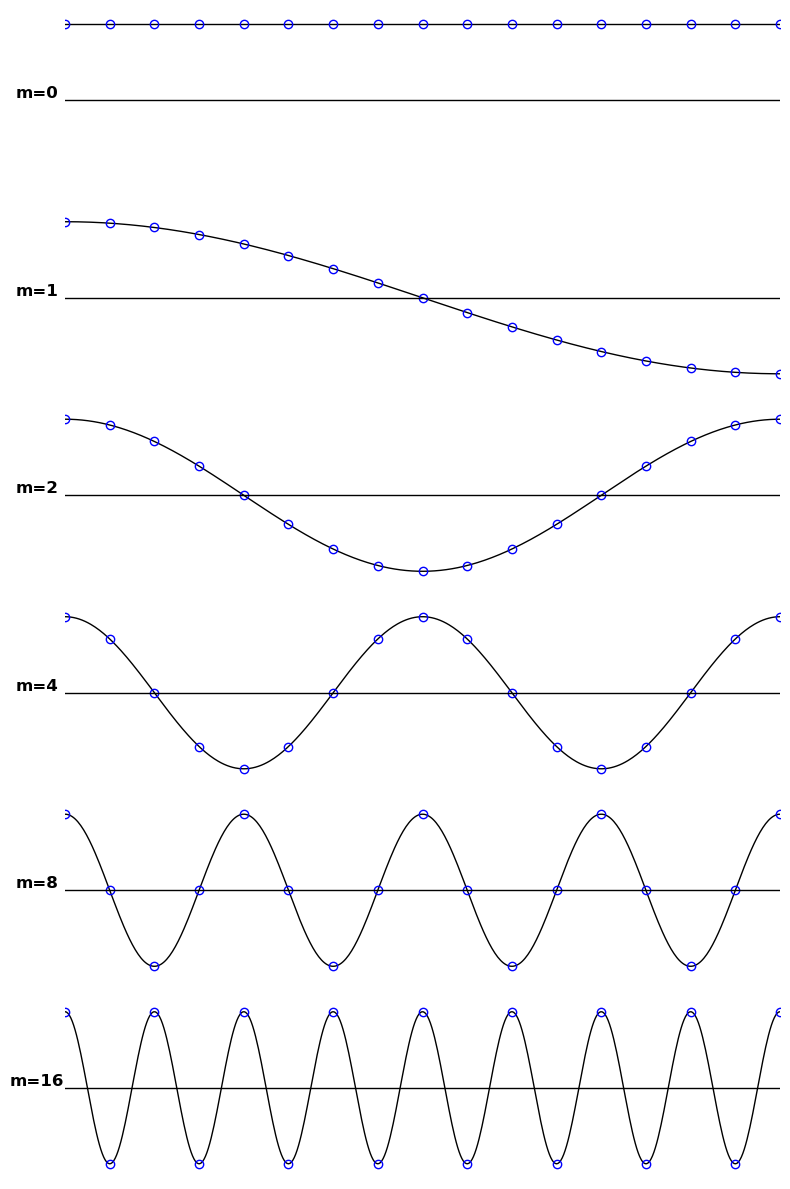

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 16
h = 1/N
x_discrete = np.linspace(0, 1, N + 1)
x_continuous = np.linspace(0, 1, 500)
m_values = [0, 1, 2, 4, 8, 16]

# Create the figure similar to the notes
fig, axes = plt.subplots(len(m_values), 1, figsize=(8, 12))

for i, m in enumerate(m_values):
    # Continuous wave for visual reference
    y_cont = np.cos(m * np.pi * x_continuous)
    # Discrete points (the actual eigenvector components)
    y_disc = np.cos(m * np.pi * x_discrete)
    
    # Plotting
    axes[i].plot(x_continuous, y_cont, 'k-', linewidth=1)  # Black continuous line
    axes[i].plot(x_discrete, y_disc, 'bo', markerfacecolor='none', markersize=6) # Blue open circles
    axes[i].axhline(0, color='black', linewidth=1) # Zero line/Axis
    
    # Clean up the plot to match the style
    axes[i].set_ylabel(f'm={m}', rotation=0, labelpad=20, fontsize=12, fontweight='bold')
    axes[i].set_ylim(-1.2, 1.2)
    axes[i].set_xlim(0, 1)
    
    # Remove ticks and spines to mimic the minimalist "notes" style
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    for spine in ['top', 'right', 'bottom', 'left']:
        axes[i].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

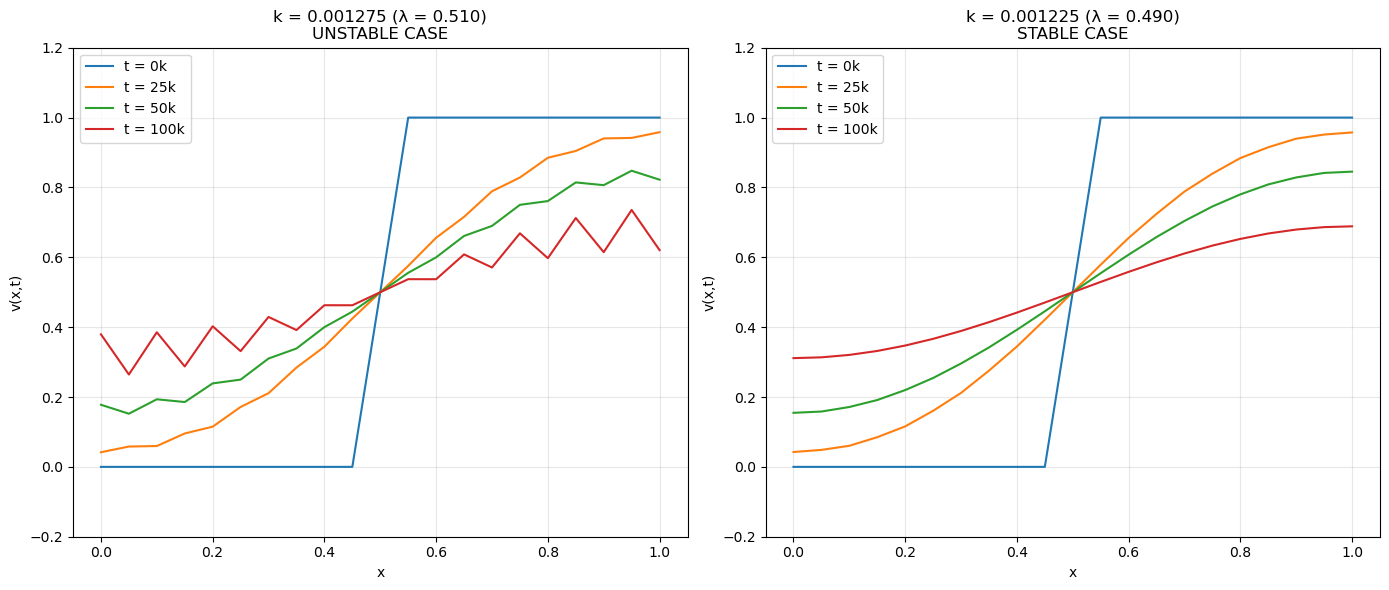

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def solve_heat_neumann(h, k, n_steps):
    N = int(1/h)
    x = np.linspace(0, 1, N + 1)
    lam = k / h**2
    
    # 1. Initialize u at t=0
    # v(x,0) = 0 if x < 0.5, 0.5 if x = 0.5, 1 if x > 0.5
    u = np.zeros(N + 1)
    u[x > 0.5] = 1.0
    u[x == 0.5] = 0.5
    
    # To store results at specific steps
    results = {0: u.copy()}
    
    # 2. Construct the Neumann iteration matrix G = I + kA
    # Recall A has 2s on the corners due to u_{-1}=u_1 and u_{N+1}=u_{N-1}
    G = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        if i == 0:
            G[i, 0], G[i, 1] = 1 - 2*lam, 2*lam
        elif i == N:
            G[i, N-1], G[i, N] = 2*lam, 1 - 2*lam
        else:
            G[i, i-1], G[i, i], G[i, i+1] = lam, 1 - 2*lam, lam
            
    # 3. Time stepping
    for n in range(1, max(n_steps) + 1):
        u = G @ u
        if n in n_steps:
            results[n] = u.copy()
            
    return x, results, lam

# Parameters from the problem
h = 0.05
k_vals = [0.001275, 0.001225]
steps_to_plot = [25, 50, 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, k in enumerate(k_vals):
    x, results, lam = solve_heat_neumann(h, k, steps_to_plot)
    
    ax = axes[idx]
    for step, u_val in sorted(results.items()):
        ax.plot(x, u_val, label=f't = {step}k')
    
    status = "UNSTABLE" if lam > 0.5 else "STABLE"
    ax.set_title(f'k = {k} (λ = {lam:.3f})\n{status} CASE')
    ax.set_xlabel('x')
    ax.set_ylabel('v(x,t)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.2, 1.2) # Keeping scale consistent to see blow-up

plt.tight_layout()
plt.show()

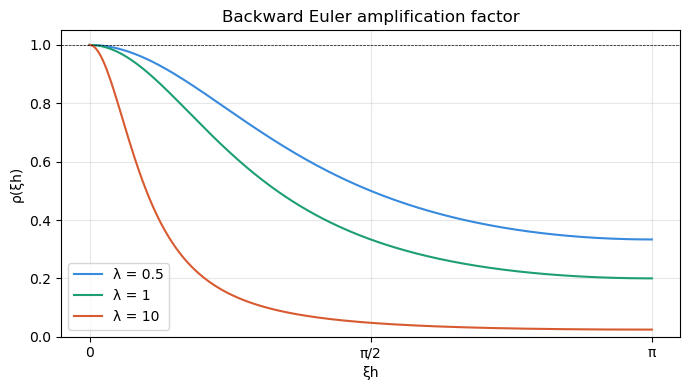

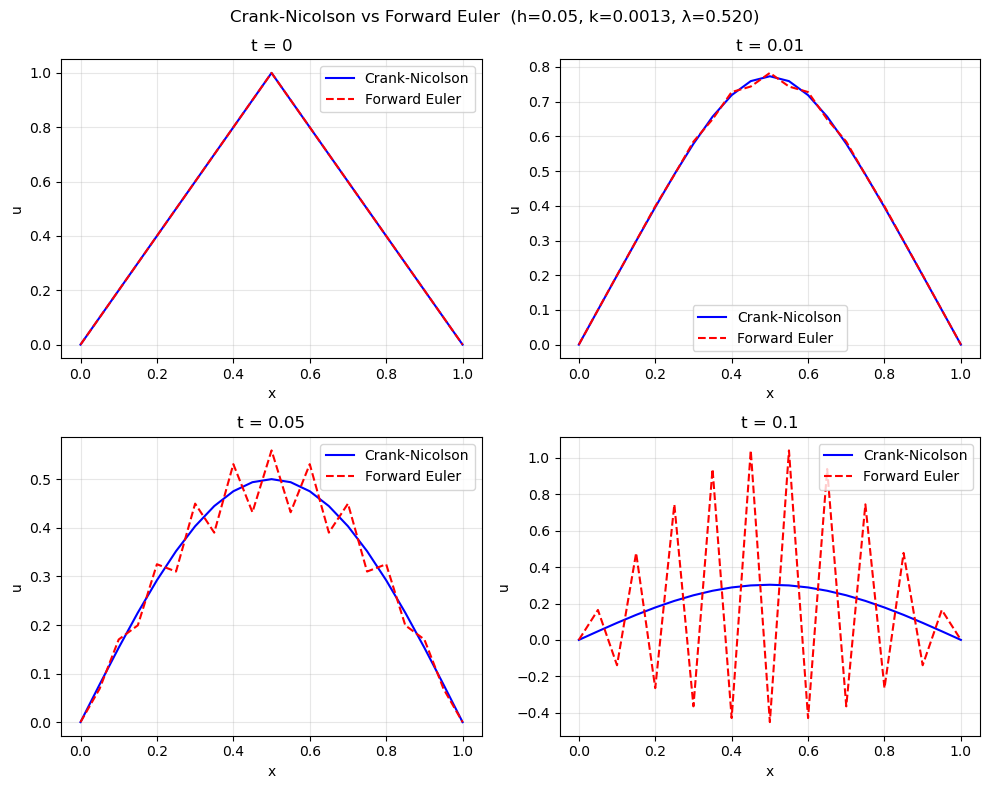

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ── Problem 3: Amplification factor for Backward Euler ────────────
xh = np.linspace(0, np.pi, 300)
lambdas = [0.5, 1, 10]
colors = ['#378ADD', '#1D9E75', '#D85A30']

fig, ax = plt.subplots(figsize=(7, 4))
for lam, col in zip(lambdas, colors):
    rho = 1 / (1 + 4*lam*np.sin(xh/2)**2)
    ax.plot(xh, rho, color=col, label=f'λ = {lam}')

ax.set_xlabel('ξh')
ax.set_ylabel('ρ(ξh)')
ax.set_xticks([0, np.pi/2, np.pi], ['0', 'π/2', 'π'])
ax.set_ylim(0, 1.05)
ax.axhline(1, color='k', linewidth=0.5, linestyle='--')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.legend()
ax.set_title('Backward Euler amplification factor')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Problem 4: Crank-Nicolson vs Forward Euler ────────────────────
h = 0.05
k = 0.0013
lam = k / h**2
x = np.arange(h, 1, h)
N = len(x)

u0 = 1 - 2*np.abs(x - 0.5)

# CN tridiagonal LU factorization (done once)
d   = (1 + lam) * np.ones(N)
off = (-lam/2)  * np.ones(N-1)

d_fac  = d.copy()
off_fac = off.copy()
for i in range(1, N):
    m = off_fac[i-1] / d_fac[i-1]
    d_fac[i] -= m * off_fac[i-1]
    off_fac[i-1] = m

def thomas_solve(d_fac, off_fac, rhs):
    n = len(rhs)
    b = rhs.copy()
    for i in range(1, n):
        b[i] -= off_fac[i-1] * b[i-1]
    b[-1] /= d_fac[-1]
    for i in range(n-2, -1, -1):
        b[i] = (b[i] - off[i] * b[i+1]) / d_fac[i]
    return b

def apply_rhs_cn(u):
    r = u.copy()
    r[1:-1] += (lam/2) * (u[:-2] - 2*u[1:-1] + u[2:])
    r[0]    += (lam/2) * (        - 2*u[0]    + u[1] )
    r[-1]   += (lam/2) * (u[-2]   - 2*u[-1]          )
    return r

def apply_fe(u):
    u_new = u.copy()
    u_new[1:-1] += lam * (u[:-2] - 2*u[1:-1] + u[2:])
    u_new[0]    += lam * (        - 2*u[0]    + u[1] )
    u_new[-1]   += lam * (u[-2]   - 2*u[-1]          )
    return u_new

snapshot_times = [0, 0.01, 0.05, 0.1]
snaps_cn = {}
snaps_fe = {}

u_cn = u0.copy()
u_fe = u0.copy()
t = 0.0

def save(t):
    for st in snapshot_times:
        if abs(t - st) < k/2:
            snaps_cn[st] = np.r_[0, u_cn, 0]
            snaps_fe[st] = np.r_[0, u_fe, 0]

save(t)
nsteps = int(round(0.1 / k))
for _ in range(nsteps):
    u_cn = thomas_solve(d_fac, off_fac, apply_rhs_cn(u_cn))
    u_fe = apply_fe(u_fe)
    t += k
    save(t)

x_full = np.r_[0, x, 1]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, st in zip(axes.flat, snapshot_times):
    ax.plot(x_full, snaps_cn[st], 'b-',  label='Crank-Nicolson')
    ax.plot(x_full, snaps_fe[st], 'r--', label='Forward Euler')
    ax.set_title(f't = {st}')
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Crank-Nicolson vs Forward Euler  (h={h}, k={k}, λ={lam:.3f})')
plt.tight_layout()
plt.show()